In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import time
rng = np.random.default_rng(42)

In [2]:
def true_mixture_2d(Z):
    """
    Z: (M, 2)
    returns: (M,)
    """
    INV_2PI = 1.0 / (2.0 * np.pi)

    def component_pdf(Z, mean, scale):
        diff = (Z - mean) / scale
        sq_norm = np.sum(diff**2, axis=1)
        return (1 / (scale**2)) * INV_2PI * np.exp(-0.5 * sq_norm)

    f1 = component_pdf(Z, np.array([2.0, 2.0]), 0.4)
    f2 = component_pdf(Z, np.array([5.0, 5.0]), 0.7)
    f3 = component_pdf(Z, np.array([8.0, 8.0]), 0.5)

    return 0.4 * f1 + 0.3 * f2 + 0.3 * f3
    
def sample_mixture_2d(N, rng):
    weights = [0.4, 0.3, 0.3]
    means = [
        np.array([2.0, 2.0]),
        np.array([5.0, 5.0]),
        np.array([8.0, 8.0])
    ]
    scales = [0.4, 0.7, 0.5]

    comps = rng.choice(3, size=N, p=weights)

    X = np.empty((N, 2))

    for k in range(3):
        idx = comps == k
        nk = np.sum(idx)
        if nk > 0:
            X[idx] = rng.normal(loc=means[k], scale=scales[k], size=(nk, 2))

    return X


def generate_2d_data(N, rng = np.random.default_rng(42)):
    """
    X: (N, 2)  -> true data samples
    Z: (M, 2)  -> uniform grid with M ~ O(N)
    """

    # ---- Step 1: sample true 2D data ----
    X = sample_mixture_2d(N, rng)

    # ---- Step 2: build uniform grid ----
    n_side = int(np.sqrt(N)) + 1  # √N points per dimension

    mean = X.mean(axis=0)
    std = X.std(axis=0)
    
    k = 3
    
    z1 = np.linspace(mean[0] - k*std[0], mean[0] + k*std[0], n_side)
    z2 = np.linspace(mean[1] - k*std[1], mean[1] + k*std[1], n_side)
    
    Z1, Z2 = np.meshgrid(z1, z2, indexing='ij')
    Z = np.stack([Z1.ravel(), Z2.ravel()], axis=1)

    return X, Z



# Dense

## Implementation

In [3]:
class KDE2D_Dense:
    def __init__(self, X, Z):
        """
        X: (N,2) data points
        Z: (M,2) evaluation points
        """
        self.X = X
        self.Z = Z
        self.N = X.shape[0]
        self.M = Z.shape[0]
        
    # --- Build T ---
    def compute_T(self):
        # X: (N,2)
        # Z: (M,2)
    
        cond1 = self.X[:, 0][None, :] <= self.Z[:, 0][:, None]  # (M,N)
        cond2 = self.X[:, 1][None, :] <= self.Z[:, 1][:, None]  # (M,N)
    
        T = np.mean(cond1 & cond2, axis=1)  # (M,)
        return T
        
    # --- K(a) ---
    def K(self, A):
        # A: (M,N,2)
        a1 = A[:,:,0]
        a2 = A[:,:,1]
        return norm.cdf(a1) * norm.cdf(a2)

    # --- ∇K(a)  ---
    def grad_K(self, A):
        a1 = A[:,:,0]
        a2 = A[:,:,1]

        g1 = norm.pdf(a1) * norm.cdf(a2)
        g2 = norm.cdf(a1) * norm.pdf(a2)

        return np.stack([g1, g2], axis=2)  # (M,N,2)

    # --- Build Kmat ---
    def compute_Kmat(self, h):
        # a_{k,j} = (z_k - x_j)/h_j
        diff = self.Z[:,None,:] - self.X[None,:,:]   # (M,N,2)
        A = diff / h[None,:,None]
        return self.K(A), A

    # --- Build D ---
    def compute_D(self, h, A):
        diff = self.Z[:,None,:] - self.X[None,:,:]   # (M,N,2)

        gradK = self.grad_K(A)  # (M,N,2)

        # dot product: ∇K^T * (z-x)
        dot = np.sum(gradK * diff, axis=2)

        D = - dot / (h[None,:]**2)
        return D

    # --- forward ---
    def forward(self, h):
        Kmat, A = self.compute_Kmat(h)
        Fhat = (1/self.N) * Kmat @ np.ones(self.N)
        return Fhat, Kmat, A

    # --- Gradient ---
    def gradient(self, h, Fhat, T, A):
        r = Fhat - T
        D = self.compute_D(h, A)
        grad = (2/self.N) * (D.T @ r)
        return grad

    # --- Optimize ---
    def fit(self, h_init, lr=0.1, iters=100, pilot_stride=3,
            adam_beta1=0.9, adam_beta2=0.999, adam_eps=1e-8):
        """
        Sparse-bump + Adam optimisation.
    
        pilot_stride : optimise only every `pilot_stride`-th bandwidth;
                       the rest are linearly interpolated from their
                       nearest pilots.  In 2-D the kernel is already a
                       product of two 1-D kernels, so full per-point
                       resolution is rarely needed.
        Adam         : adaptive per-parameter lr with momentum —
                       critical here because ∂L/∂h_j magnitudes span
                       several orders of magnitude across the 2-D domain.
        """
        # ---- pilot indices (every 3rd point) ----
        pilot_idx = np.arange(0, self.N, pilot_stride)   # shape (P,)
        P = len(pilot_idx)
    
        def expand_h(h_pilot):
            """Broadcast P pilot bandwidths to all N points."""
            h_full = np.empty(self.N)
            for p, pi in enumerate(pilot_idx):
                lo = pi
                hi = pilot_idx[p + 1] if p + 1 < P else self.N
                h_full[lo:hi] = h_pilot[p]
            return h_full
    
        h_pilot = h_init[pilot_idx].copy()
        T = self.compute_T()
    
        losses = []
    
        # Adam state (in log-space)
        alpha_pilot = np.log(h_pilot)
        m = np.zeros(P)   # 1st moment
        v = np.zeros(P)   # 2nd moment
    
        time_build = 0.0
        time_grad  = 0.0
    
        tg = time.time()
        for i in range(iters):
            h = expand_h(np.exp(alpha_pilot))
    
            # ---- Forward ----
            Fhat, Kmat, A = self.forward(h)
    
            # ---- Loss ----
            loss = np.linalg.norm(Fhat - T)**2
            losses.append(loss)
    
            # ---- Gradient (full N, then aggregate to pilots) ----
            grad = self.gradient(h, Fhat, T, A)   # shape (N,)
            # chain-rule into log-space: ∂L/∂α_j = ∂L/∂h_j * h_j
            grad_alpha_full = grad * h             # (N,)
            # sum contributions that were broadcast to each pilot
            grad_alpha_pilot = np.zeros(P)
            for p, pi in enumerate(pilot_idx):
                lo = pi
                hi = pilot_idx[p + 1] if p + 1 < P else self.N
                grad_alpha_pilot[p] = grad_alpha_full[lo:hi].sum()
    
            # ---- Adam update ----
            t_adam = i + 1
            m = adam_beta1 * m + (1 - adam_beta1) * grad_alpha_pilot
            v = adam_beta2 * v + (1 - adam_beta2) * grad_alpha_pilot**2
            m_hat = m / (1 - adam_beta1**t_adam)
            v_hat = v / (1 - adam_beta2**t_adam)
            alpha_pilot -= lr * m_hat / (np.sqrt(v_hat) + adam_eps)
    
            if i % 10 == 0:
                print(f"Iter {i}, Loss = {loss:.6f}")
    
        time_grad += time.time() - tg
    
        # Expand optimised pilots back to full N
        h_opt = expand_h(np.exp(alpha_pilot))
    
        return {
            "h_opt": h_opt,
            "losses": losses,
            "time_build": time_build,
            "time_grad": time_grad,
            "total_time": time_build + time_grad
        }

    def kde_estimate(self, h, Z_eval):
        diff = Z_eval[:,None,:] - self.X[None,:,:]
        A = diff / h[None,:,None]
    
        a1 = A[:,:,0]
        a2 = A[:,:,1]
    
        kappa = norm.pdf(a1) * norm.pdf(a2)
    
        fhat = (1/self.N) * np.sum(kappa / (h[None,:]**2), axis=1)
        return fhat

# HODLR

### KDTree utils

In [4]:
import numpy as np
import matplotlib.pyplot as plt


#  MERGE 
def merge_sorted_lists(list1, list2, index):
    N1, N2 = list1.shape[0], list2.shape[0]
    dim = list1.shape[1]

    final_list = np.zeros((N1 + N2, dim))

    j1 = j2 = j = 0

    while j1 < N1 and j2 < N2:
        if list1[j1, index] < list2[j2, index]:
            final_list[j] = list1[j1]
            j1 += 1
        else:
            final_list[j] = list2[j2]
            j2 += 1
        j += 1

    while j1 < N1:
        final_list[j] = list1[j1]
        j1 += 1
        j += 1

    while j2 < N2:
        final_list[j] = list2[j2]
        j2 += 1
        j += 1

    return final_list


#  MERGE SORT 
def merge_sort(locations, index):
    N = locations.shape[0]

    if N == 1:
        return locations

    N_left = N // 2

    left = locations[:N_left]
    right = locations[N_left:]

    left_sorted = merge_sort(left, index)
    right_sorted = merge_sort(right, index)

    return merge_sorted_lists(left_sorted, right_sorted, index)


#  KD SORT 
def get_kd_tree_sorted(locations, index=0):
    N, dims = locations.shape

    if N == 1:
        return locations

    axis = index % dims

    # Sort along current axis
    locations = merge_sort(locations, axis)

    N_left = N // 2

    # Split
    left = locations[:N_left]
    right = locations[N_left:]

    # Recursive KD sorting
    left_sorted = get_kd_tree_sorted(left, index + 1)
    right_sorted = get_kd_tree_sorted(right, index + 1)

    return np.vstack((left_sorted, right_sorted))

def get_kd_permutation(points):
    sorted_pts = get_kd_tree_sorted(points)

    perm = []
    for pt in sorted_pts:
        idx = np.where((points == pt).all(axis=1))[0][0]
        perm.append(idx)

    return np.array(perm)

### Cheby utils

In [5]:
#  Chebyshev core 
def cheb_points(p):
    return np.cos((2*np.arange(p)+1)*np.pi/(2*p))

def scale11(x, a, b):
    return (2*x - (a+b)) / (b-a)

def scale_to_box(x, a, b):
    return 0.5*(a+b) + 0.5*(b-a)*x

def chebyshev_polynomials(x, p):
    x = np.asarray(x)
    T = np.zeros((len(x), p))
    T[:,0] = 1.0
    if p > 1:
        T[:,1] = x
    for n in range(2, p):
        T[:,n] = 2*x*T[:,n-1] - T[:,n-2]
    return T


#  Bounding box 
def compute_bounds(X):
    return [(X[:,0].min(), X[:,0].max()),
            (X[:,1].min(), X[:,1].max())]


#  Build Chebyshev basis (U / V) 
def build_cheb_basis(X, bounds, p):
    x_scaled = scale11(X[:,0], bounds[0][0], bounds[0][1])
    y_scaled = scale11(X[:,1], bounds[1][0], bounds[1][1])

    Tx = chebyshev_polynomials(x_scaled, p)
    Ty = chebyshev_polynomials(y_scaled, p)

    Phi = np.zeros((X.shape[0], p*p))

    for i in range(p):
        for j in range(p):
            Phi[:, i*p + j] = Tx[:, i] * Ty[:, j]

    return Phi


#  Build S using Cheb nodes 
def build_S_cheb(bounds_Z, bounds_X, p, h_block):

    cx = cheb_points(p)
    cy = cheb_points(p)

    zx = scale_to_box(cx, bounds_Z[0][0], bounds_Z[0][1])
    zy = scale_to_box(cy, bounds_Z[1][0], bounds_Z[1][1])

    xx = scale_to_box(cx, bounds_X[0][0], bounds_X[0][1])
    xy = scale_to_box(cy, bounds_X[1][0], bounds_X[1][1])

    Z_nodes = np.array([(i,j) for i in zx for j in zy])
    X_nodes = np.array([(i,j) for i in xx for j in xy])

    diff = Z_nodes[:,None,:] - X_nodes[None,:,:]
    A = diff / h_block

    return norm.cdf(A[:,:,0]) * norm.cdf(A[:,:,1])

def build_S_cheb_D(bounds_Z, bounds_X, p, h_block):

    # Chebyshev nodes in [-1,1]
    cx = cheb_points(p)
    cy = cheb_points(p)

    # Map to physical domain
    zx = scale_to_box(cx, bounds_Z[0][0], bounds_Z[0][1])
    zy = scale_to_box(cy, bounds_Z[1][0], bounds_Z[1][1])

    xx = scale_to_box(cx, bounds_X[0][0], bounds_X[0][1])
    xy = scale_to_box(cy, bounds_X[1][0], bounds_X[1][1])

    # Tensor grid
    Z_nodes = np.array([(i, j) for i in zx for j in zy])
    X_nodes = np.array([(i, j) for i in xx for j in xy])

    # Pairwise differences
    diff = Z_nodes[:, None, :] - X_nodes[None, :, :]
    A = diff / h_block

    a1 = A[:, :, 0]
    a2 = A[:, :, 1]

    # ∇K components (same as dense case)
    g1 = norm.pdf(a1) * norm.cdf(a2)
    g2 = norm.cdf(a1) * norm.pdf(a2)

    gradK = np.stack([g1, g2], axis=2)

    # dot product: ∇K ⋅ (z - x)
    dot = np.sum(gradK * diff, axis=2)

    # final D
    D = -dot / (h_block**2)

    return D

### Implementation

In [6]:
import numpy as np
from scipy.stats import norm
from numpy.linalg import svd

# HODLR Node

class HODLRNode:
    def __init__(self, idx_row, idx_col, X, Z, leaf_size=32, method="svd", rank=20):
        self.method = method
        self.rank = rank
        self.idx_row = idx_row
        self.idx_col = idx_col
        self.X = X
        self.Z = Z
        self.leaf_size = leaf_size

        self.is_leaf = False

        # children
        self.A11 = None
        self.A22 = None

        # index splits
        self.I1 = self.I2 = None
        self.J1 = self.J2 = None

        # low-rank factors
        self.U12 = self.S12 = self.V12 = None
        self.U21 = self.S21 = self.V21 = None
        # for D (gradient)
        self.U12_D = self.S12_D = self.V12_D = None
        self.U21_D = self.S21_D = self.V21_D = None

        self.build()

    def build(self):
        if len(self.idx_row) <= self.leaf_size or len(self.idx_col) <= self.leaf_size:
            self.is_leaf = True
            return

        mid_r = len(self.idx_row)//2
        mid_c = len(self.idx_col)//2

        self.I1 = self.idx_row[:mid_r]
        self.I2 = self.idx_row[mid_r:]

        self.J1 = self.idx_col[:mid_c]
        self.J2 = self.idx_col[mid_c:]

        self.A11 = HODLRNode(self.I1, self.J1, self.X, self.Z, self.leaf_size, self.method, self.rank)
        self.A22 = HODLRNode(self.I2, self.J2, self.X, self.Z, self.leaf_size, self.method, self.rank)


    # LOW RANK (off-diagonal)

    def compute_low_rank(self, h, rank=None):
        if self.is_leaf:
            return
    
        if self.method == "svd":
            # SVD
            Z1 = self.Z[self.I1]
            X2 = self.X[self.J2]
    
            diff = Z1[:,None,:] - X2[None,:,:]
            A = diff / h[self.J2][None,:,None]
            K12 = norm.cdf(A[:,:,0]) * norm.cdf(A[:,:,1])
    
            U, S, VT = svd(K12, full_matrices=False)
            r = min(self.rank, len(S))
            self.U12, self.S12, self.V12 = U[:,:r], S[:r], VT[:r,:]
            
            # ----- D12 -----
            g1 = norm.pdf(A[:,:,0]) * norm.cdf(A[:,:,1])
            g2 = norm.cdf(A[:,:,0]) * norm.pdf(A[:,:,1])
            
            gradK = np.stack([g1, g2], axis=2)
            dot = np.sum(gradK * diff, axis=2)
            
            D12 = -dot / (h[self.J2][None,:]**2)
            
            U, S, VT = svd(D12, full_matrices=False)
            r = min(self.rank, len(S))
            self.U12_D, self.S12_D, self.V12_D = U[:,:r], S[:r], VT[:r,:]

            
            Z2 = self.Z[self.I2]
            X1 = self.X[self.J1]
    
            diff = Z2[:,None,:] - X1[None,:,:]
            A = diff / h[self.J1][None,:,None]
            K21 = norm.cdf(A[:,:,0]) * norm.cdf(A[:,:,1])
    
            U, S, VT = svd(K21, full_matrices=False)
            r = min(self.rank, len(S))
            self.U21, self.S21, self.V21 = U[:,:r], S[:r], VT[:r,:]
            
            # ----- D21 -----
            g1 = norm.pdf(A[:,:,0]) * norm.cdf(A[:,:,1])
            g2 = norm.cdf(A[:,:,0]) * norm.pdf(A[:,:,1])
            
            gradK = np.stack([g1, g2], axis=2)
            dot = np.sum(gradK * diff, axis=2)
            
            D21 = -dot / (h[self.J1][None,:]**2)
            
            U, S, VT = svd(D21, full_matrices=False)
            r = min(self.rank, len(S))
            self.U21_D, self.S21_D, self.V21_D = U[:,:r], S[:r], VT[:r,:]


       
        elif self.method == "cheb":
            p = int(np.sqrt(self.rank))
        
            bounds_X1 = compute_bounds(self.X[self.J1])
            bounds_X2 = compute_bounds(self.X[self.J2])
            bounds_Z1 = compute_bounds(self.Z[self.I1])
            bounds_Z2 = compute_bounds(self.Z[self.I2])
        
            # build Chebyshev bases (THIS is the main fix)
            self.U12 = build_cheb_basis(self.Z[self.I1], bounds_Z1, p)
            self.V12 = build_cheb_basis(self.X[self.J2], bounds_X2, p)
        
            self.U21 = build_cheb_basis(self.Z[self.I2], bounds_Z2, p)
            self.V21 = build_cheb_basis(self.X[self.J1], bounds_X1, p)
        
            # store bounds (needed for S)
            self.bounds_12 = (bounds_Z1, bounds_X2)
            self.bounds_21 = (bounds_Z2, bounds_X1)
    
        # recurse
        self.A11.compute_low_rank(h, rank)
        self.A22.compute_low_rank(h, rank)


    # MATVEC: K @ v (v is 1 here btw)

    def matvec_K(self, v, h):
        if self.is_leaf:
            Zr = self.Z[self.idx_row]
            Xc = self.X[self.idx_col]

            diff = Zr[:,None,:] - Xc[None,:,:]
            A = diff / h[self.idx_col][None,:,None]

            K = norm.cdf(A[:,:,0]) * norm.cdf(A[:,:,1])
            return K @ v[self.idx_col]

        # split vector
        v1 = v[self.J1]
        v2 = v[self.J2]

        # diagonal
        y1 = self.A11.matvec_K(v, h)
        y2 = self.A22.matvec_K(v, h)

        # off-diagonal
        if self.method == "svd":
            y1 += self.U12 @ (self.S12 * (self.V12 @ v2))
            y2 += self.U21 @ (self.S21 * (self.V21 @ v1))
        
        elif self.method == "cheb":
            p = int(np.sqrt(self.rank))
        
            # scalar bandwidth per block
            h12 = np.mean(h[self.J2])
            h21 = np.mean(h[self.J1])
        
            bounds_Z1, bounds_X2 = self.bounds_12
            bounds_Z2, bounds_X1 = self.bounds_21
        
            S12 = build_S_cheb(bounds_Z1, bounds_X2, p, h12)
            S21 = build_S_cheb(bounds_Z2, bounds_X1, p, h21)
        
            y1 += self.U12 @ (S12 @ (self.V12.T @ v2))
            y2 += self.U21 @ (S21 @ (self.V21.T @ v1))

        return np.concatenate([y1, y2])


    # MATVEC: D^T @ r

    def matvec_Dt(self, r, h):
    
        if self.is_leaf:
            Zr = self.Z[self.idx_row]
            Xc = self.X[self.idx_col]
    
            diff = Zr[:,None,:] - Xc[None,:,:]
            A = diff / h[self.idx_col][None,:,None]
    
            a1 = A[:,:,0]
            a2 = A[:,:,1]
    
            g1 = norm.pdf(a1) * norm.cdf(a2)
            g2 = norm.cdf(a1) * norm.pdf(a2)
    
            gradK = np.stack([g1, g2], axis=2)
            dot = np.sum(gradK * diff, axis=2)
    
            D = -dot / (h[self.idx_col][None,:]**2)
    
            return D.T @ r
    
    
        # split residual
        r1 = r[:len(self.I1)]
        r2 = r[len(self.I1):]
    
        # diagonal
        g1 = self.A11.matvec_Dt(r1, h)
        g2 = self.A22.matvec_Dt(r2, h)
    
        # OFF-DIAGONAL (NEW)
    
        if self.method == "svd":
            g1 += self.V21_D.T @ (self.S21_D * (self.U21_D.T @ r2))
            g2 += self.V12_D.T @ (self.S12_D * (self.U12_D.T @ r1))
    
    
        elif self.method == "cheb":
            p = int(np.sqrt(self.rank))
    
            h12 = np.mean(h[self.J2])
            h21 = np.mean(h[self.J1])
    
            bounds_Z1, bounds_X2 = self.bounds_12
            bounds_Z2, bounds_X1 = self.bounds_21
    
            S12_D = build_S_cheb_D(bounds_Z1, bounds_X2, p, h12)
            S21_D = build_S_cheb_D(bounds_Z2, bounds_X1, p, h21)
    
            g1 += self.V21 @ (S21_D.T @ (self.U21.T @ r2))
            g2 += self.V12 @ (S12_D.T @ (self.U12.T @ r1))
    
    
        return np.concatenate([g1, g2])
        

In [7]:
# KDE HODLR CLASS
class KDE2D_HODLR:
    def __init__(self, X, Z, leaf_size=32, method="svd", rank=20):
        self.X_orig = X
        self.Z_orig = Z

        self.N = X.shape[0]
        self.M = Z.shape[0]

        # KD orderingw
        self.row_perm = get_kd_permutation(Z)
        self.col_perm = get_kd_permutation(X)

        self.row_inv = np.argsort(self.row_perm)
        self.col_inv = np.argsort(self.col_perm)

        self.X = X[self.col_perm]
        self.Z = Z[self.row_perm]

        idx_row = np.arange(self.M)
        idx_col = np.arange(self.N)

        self.root = HODLRNode(idx_row, idx_col, self.X, self.Z, leaf_size, method, rank)

    #  Empirical CDF target 
    # def compute_T(self):
    #     T = np.zeros(self.M)
    #     for k in range(self.M):
    #         T[k] = np.mean(
    #             (self.X_orig[:,0] <= self.Z_orig[k,0]) &
    #             (self.X_orig[:,1] <= self.Z_orig[k,1])
    #         )
    #     return T

    def compute_T(self):
        # X: (N,2)
        # Z: (M,2)
    
        cond1 = self.X_orig[:, 0][None, :] <= self.Z_orig[:, 0][:, None]  # (M,N)
        cond2 = self.X_orig[:, 1][None, :] <= self.Z_orig[:, 1][:, None]  # (M,N)
    
        T = np.mean(cond1 & cond2, axis=1)  # (M,)
        return T

    #  Forward 
    def forward(self, h):
        h_perm = h[self.col_perm]

        ones = np.ones(self.N)
        Fhat_perm = (1/self.N) * self.root.matvec_K(ones, h_perm)

        return Fhat_perm[self.row_inv]

    #  Gradient 
    def gradient(self, h, Fhat, T):
        h_perm = h[self.col_perm]

        r = Fhat - T
        r_perm = r[self.row_perm]

        grad_perm = (2/self.N) * self.root.matvec_Dt(r_perm, h_perm)

        grad = np.zeros_like(h)
        grad[self.col_perm] = grad_perm

        return grad

    #  Optimize 
    def fit(self, h_init, lr=1e-3, iters=100, pilot_stride=3,
            adam_beta1=0.9, adam_beta2=0.999, adam_eps=1e-8):
        """
        Sparse-bump + Adam optimisation.
    
        pilot_stride : every `pilot_stride`-th data point owns a free
                       bandwidth; all others copy their nearest pilot.
                       In 2-D, the kernel factorises over dimensions so
                       spatial locality already provides smoothness —
                       no need for N independent bumps.
        Adam         : handles the ill-conditioned log-space loss that
                       arises when h_j vary widely across the 2-D domain.
        """
        # ---- pilot indices ----
        pilot_idx = np.arange(0, self.N, pilot_stride)
        P = len(pilot_idx)
            
        def expand_h(h_pilot):
            h_full_perm = np.empty(self.N)
            for p, pi in enumerate(pilot_idx):
                lo = pi
                hi = pilot_idx[p + 1] if p + 1 < P else self.N
                h_full_perm[lo:hi] = h_pilot[p]

            # map back to original ordering
            h_full = np.empty(self.N)
            h_full[self.col_perm] = h_full_perm
            return h_full
    
        h_perm = h_init[self.col_perm]
        h_pilot = h_perm[pilot_idx].copy()
        T = self.compute_T()
    
        losses = []
    
        time_build = 0.0
        time_grad  = 0.0
    
        # Adam state (log-space)
        alpha_pilot = np.log(h_pilot)
        m = np.zeros(P)
        v = np.zeros(P)
    
        # ---- Cheb: one-time build with initial h ----
        if self.root.method == "cheb":
            t0 = time.time()
            self.root.compute_low_rank(expand_h(np.exp(alpha_pilot)), rank=30)
            time_build += time.time() - t0
    
        tg = time.time()
        for i in range(iters):
            h = expand_h(np.exp(alpha_pilot))
    
            # ---- SVD: per-iteration low-rank ----
            if self.root.method == "svd":
                self.root.compute_low_rank(h, rank=30)
    
            # ---- Forward ----
            Fhat = self.forward(h)
    
            # ---- Loss ----
            loss = np.linalg.norm(Fhat - T)**2
            losses.append(loss)
    
            # ---- Gradient (full N → aggregate to pilots) ----
            grad = self.gradient(h, Fhat, T)       # (N,)
            grad_alpha_full = grad * h              # log-space chain rule
            grad_alpha_pilot = np.zeros(P)
            for p, pi in enumerate(pilot_idx):
                lo = pi
                hi = pilot_idx[p + 1] if p + 1 < P else self.N
                grad_alpha_pilot[p] = grad_alpha_full[lo:hi].sum()
    
            # ---- Adam update ----
            t_adam = i + 1
            m = adam_beta1 * m + (1 - adam_beta1) * grad_alpha_pilot
            v = adam_beta2 * v + (1 - adam_beta2) * grad_alpha_pilot**2
            m_hat = m / (1 - adam_beta1**t_adam)
            v_hat = v / (1 - adam_beta2**t_adam)
            alpha_pilot -= lr * m_hat / (np.sqrt(v_hat) + adam_eps)
    
            if i % 10 == 0:
                print(f"Iter {i}, Loss = {loss:.6f}")
    
        time_grad += time.time() - tg
    
        h_opt = expand_h(np.exp(alpha_pilot))
    
        return {
            "h_opt": h_opt,
            "losses": losses,
            "time_build": time_build,
            "time_grad": time_grad,
            "total_time": time_build + time_grad
        }
        
    #  KDE PDF estimate 
    def kde_estimate(self, h, Z_eval):
        diff = Z_eval[:,None,:] - self.X_orig[None,:,:]
        A = diff / h[None,:,None]

        a1 = A[:,:,0]
        a2 = A[:,:,1]

        kappa = norm.pdf(a1) * norm.pdf(a2)
        fhat = (1/self.N) * np.sum(kappa / (h[None,:]**2), axis=1)

        return fhat

# Scaling Expmt

In [8]:
def enrich_result(res, X, Z):
    res['X'] = X
    res['Z'] = Z
    res['N'] = X.shape[0]
    res['final_loss'] = res['losses'][-1]
    return res

In [9]:
def run_scaling_experiment_2d(
    N_values=[1000, 2000, 3000],
    ranks=[5, 8],
    leaf_sizes=[16],
    seed=42
):

    rng = np.random.default_rng(seed)

    results = {
        'dense': [],
        'svd': {},
        'cheb': {}
    }

    print("\n" + "="*80)
    print("2D KDE: DENSE vs SVD vs CHEB")
    print("="*80)

    for N in N_values:
        print(f"\nN = {N}")

        X,Z = generate_2d_data(N, rng)

        # IMPORTANT: bandwidth is per data point (N^2)
        h_init = 0.1 * np.ones(X.shape[0])

        #  DENSE 
        print("  [DENSE]...", end=" ")

        dense_model = KDE2D_Dense(X, Z)
        res = dense_model.fit(h_init, lr=0.05, iters=50)

        res.update({
            'X': X,
            'Z': Z,
            'N': N,
            'final_loss': res['losses'][-1]
        })

        results['dense'].append(res)

        print(f"Loss={res['final_loss']:.4f}, t={res['total_time']:.2f}s")

        #  HODLR 
        for rank in ranks:
            for leaf in leaf_sizes:

                key = f'p{rank}_l{leaf}'

                # -------- SVD --------
                if key not in results['svd']:
                    results['svd'][key] = []

                print(f"  [SVD {key}]...", end=" ")

                model = KDE2D_HODLR(X, Z, leaf_size=leaf, method="svd", rank=rank)
                res = model.fit(h_init, lr=1e-3, iters=50)

                res.update({
                    'X': X,
                    'Z': Z,
                    'N': N,
                    'final_loss': res['losses'][-1]
                })

                results['svd'][key].append(res)

                print(f"Loss={res['final_loss']:.4f}, t={res['total_time']:.2f}s")

                # -------- CHEB --------
                if key not in results['cheb']:
                    results['cheb'][key] = []

                print(f"  [CHEB {key}]...", end=" ")

                model = KDE2D_HODLR(X, Z, leaf_size=leaf, method="cheb", rank=rank)
                res = model.fit(h_init, lr=1e-3, iters=50)

                res.update({
                    'X': X,
                    'Z': Z,
                    'N': N,
                    'final_loss': res['losses'][-1]
                })

                results['cheb'][key].append(res)

                print(f"Loss={res['final_loss']:.4f}, t={res['total_time']:.2f}s")

    return results, N_values

# Plots

In [10]:
def get_x_values(N_values, use_N2):
    return [N**2 if use_N2 else N for N in N_values]

In [11]:
def create_runtime_plot_2d(results, N_values,save=True):
    N_values = get_x_values(N_values, use_N2=True)

    plt.figure()

    dense_times = [m['total_time'] for m in results['dense']]
    plt.plot(N_values, dense_times, 'ko-', lw=3, label='Dense')

    for key, lst in results['svd'].items():
        times = [m['total_time'] for m in lst]
        plt.plot(N_values, times, 'o--', label=f'SVD {key}')

    for key, lst in results['cheb'].items():
        times = [m['total_time'] for m in lst]
        plt.plot(N_values, times, 'o-', label=f'Cheb {key}')

    plt.xlabel("N")
    plt.ylabel("Time")
    plt.title("Runtime Scaling (2D)")
    plt.legend()
    plt.grid()

    if(save): plt.savefig("runtime_scaling_2d.png", dpi=200)
    plt.show()
# ===================== LOSS VS ITER =====================
# def create_loss_vs_iter_plot(results, N_values, save=True):

#     plt.figure(figsize=(12,8))

#     for i, N in enumerate(N_values):

#         plt.subplot(2,2,i+1)

#         plt.semilogy(results['dense'][i]['losses'], 'k-', lw=3, label='Dense')

#         for key, lst in results['svd'].items():
#             plt.semilogy(lst[i]['losses'], '--', label=f'SVD {key}')

#         for key, lst in results['cheb'].items():
#             plt.semilogy(lst[i]['losses'], '-', label=f'Cheb {key}')

#         plt.title(f"N = {N}")
#         plt.xlabel("Iteration")
#         plt.ylabel("Loss")
#         plt.legend()
#         plt.grid()

#     plt.tight_layout()
#     if save: plt.savefig("loss_vs_iteration_2d.png", dpi=200)
#     plt.show()


# ===================== GD TIME =====================
def create_gradient_time_plot(results, N_values, save=True):
    N_values = get_x_values(N_values, use_N2=True)
    plt.figure()

    plt.plot(N_values,
             [m['time_grad'] for m in results['dense']],
             'ko-', label='Dense')

    for key, lst in results['svd'].items():
        plt.plot(N_values,
                 [m['time_grad'] for m in lst],
                 'o--', label=f'SVD {key}')

    for key, lst in results['cheb'].items():
        plt.plot(N_values,
                 [m['time_grad'] for m in lst],
                 'o-', label=f'Cheb {key}')

    plt.xlabel("N")
    plt.ylabel("Gradient Time")
    plt.legend()
    plt.grid()

    if save: plt.savefig("gradient_time_2d.png", dpi=200)
    plt.show()


# ===================== ERROR (RMSE) =====================
def create_error_plot_2d(results, N_values, use_N2=True, save=True):

    x_vals = get_x_values(N_values, use_N2)

    plt.figure()

    # ---------- Dense ----------
    dense_err = []

    for i in range(len(N_values)):
        X = results['dense'][i]['X']
        Z = results['dense'][i]['Z']

        model = KDE2D_Dense(X, Z)
        f_true = true_mixture_2d(Z)

        f = model.kde_estimate(results['dense'][i]['h_opt'], Z)
        dense_err.append(np.sqrt(np.mean((f - f_true)**2)))

    plt.plot(x_vals, dense_err, 'ko-', lw=3, label='Dense')

    # ---------- SVD ----------
    for key, lst in results['svd'].items():

        errs = []

        for i in range(len(N_values)):
            X = results['dense'][i]['X']   # use same X,Z for consistency
            Z = results['dense'][i]['Z']

            model = KDE2D_Dense(X, Z)
            f_true = true_mixture_2d(Z)

            f = model.kde_estimate(lst[i]['h_opt'], Z)
            errs.append(np.sqrt(np.mean((f - f_true)**2)))

        plt.plot(x_vals, errs, '--', label=f'SVD {key}')

    # ---------- Cheb ----------
    for key, lst in results['cheb'].items():

        errs = []

        for i in range(len(N_values)):
            X = results['dense'][i]['X']
            Z = results['dense'][i]['Z']

            model = KDE2D_Dense(X, Z)
            f_true = true_mixture_2d(Z)

            f = model.kde_estimate(lst[i]['h_opt'], Z)
            errs.append(np.sqrt(np.mean((f - f_true)**2)))

        plt.plot(x_vals, errs, '-', label=f'Cheb {key}')

    # ---------- Labels ----------
    plt.xlabel("Data size (N²)" if use_N2 else "N")
    plt.ylabel("RMSE")
    plt.title("RMSE vs True Density (2D KDE)")
    plt.legend()
    plt.grid()

    if save:
        plt.savefig("error_vs_true_2d.png", dpi=200)

    plt.show()

# ===================== SPEEDUP =====================
def create_speedup_plot_2d(results, N_values, save=True):
    plt.figure()

    dense_times = np.array([m['total_time'] for m in results['dense']])

    for key, lst in results['cheb'].items():
        times = np.array([m['total_time'] for m in lst])
        speedup = dense_times / times
        plt.plot(N_values, speedup, 'o-', label=f'Cheb {key}')

    for key, lst in results['svd'].items():
        times = np.array([m['total_time'] for m in lst])
        speedup = dense_times / times
        plt.plot(N_values, speedup, 'o--', label=f'SVD {key}')

    plt.axhline(1, color='black', linestyle='--')

    plt.xlabel("N")
    plt.ylabel("Speedup")
    plt.title("Speedup over Dense")
    plt.legend()
    plt.grid()


    if save: plt.savefig("speedup_2d.png", dpi=200)
    plt.show()

def create_speedup_bar_plot_2d(results, N_values, use_N2=False, save_plot=True):

    fig, ax = plt.subplots(figsize=(12, 5))

    # ---- x-axis values ----
    if use_N2:
        x_labels = [N**2 for N in N_values]
    else:
        x_labels = N_values

    x_pos = np.arange(len(N_values))

    # ---- collect methods ----
    svd_keys  = list(results['svd'].keys())
    cheb_keys = list(results['cheb'].keys())

    all_methods = [('svd', k) for k in svd_keys] + [('cheb', k) for k in cheb_keys]

    n_methods = len(all_methods)
    width = 0.8 / n_methods

    colors = plt.cm.tab10(np.linspace(0, 1, n_methods))

    # ---- dense baseline ----
    dense_times = [m['total_time'] for m in results['dense']]

    for i, (method_type, key) in enumerate(all_methods):

        method_list = results[method_type][key]

        speedups = []

        for j in range(len(N_values)):
            t_method = method_list[j]['total_time']
            speedups.append(dense_times[j] / t_method)

        label = f"{'SVD' if method_type=='svd' else 'Cheb'} {key}"

        bars = ax.bar(
            x_pos + i*width,
            speedups,
            width,
            label=label,
            color=colors[i],
            alpha=0.85
        )

        # annotate
        for bar, sp in zip(bars, speedups):
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height(),
                f'{sp:.1f}x',
                ha='center',
                va='bottom',
                fontsize=8
            )

    # ---- baseline line ----
    ax.axhline(1, color='black', linestyle='--', label='Dense = 1x')

    ax.set_xlabel("Data size (N²)" if use_N2 else "N")
    ax.set_ylabel("Speedup over Dense")
    ax.set_title("Speedup Comparison (2D KDE)")

    ax.set_xticks(x_pos + (n_methods-1)*width/2)
    ax.set_xticklabels([f"{x}" for x in x_labels])

    ax.legend(fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()

    if save_plot:
        plt.savefig('speedup_bar_2d.png', dpi=150)
        print("Saved: speedup_bar_2d.png")

    plt.show()

def print_timing_breakdown_2d(results, N_values, use_N2=False):

    print("\n" + "="*100)
    print("TIMING BREAKDOWN (2D KDE)")
    print("="*100)

    header_N = "N^2" if use_N2 else "N"

    print(f"{header_N:<8} {'Method':<20} {'Total':>8} {'Build':>8} {'Grad':>8} {'Speedup':>10}")
    print("-"*80)

    for i, N in enumerate(N_values):

        display_N = N**2 if use_N2 else N

        dense = results['dense'][i]
        dense_t = dense['total_time']

        print(f"{display_N:<8} {'DENSE':<20} {dense_t:>8.3f} {'-':>8} {dense_t:>8.3f} {'1.00x':>10}")

        # ---- SVD ----
        for key, lst in results['svd'].items():
            m = lst[i]
            sp = dense_t / m['total_time']

            print(f"{display_N:<8} {('SVD_'+key):<20} "
                  f"{m['total_time']:>8.3f} {m['time_build']:>8.3f} "
                  f"{m['time_grad']:>8.3f} {sp:>10.2f}x")

        # ---- CHEB ----
        for key, lst in results['cheb'].items():
            m = lst[i]
            sp = dense_t / m['total_time']

            print(f"{display_N:<8} {('Cheb_'+key):<20} "
                  f"{m['total_time']:>8.3f} {m['time_build']:>8.3f} "
                  f"{m['time_grad']:>8.3f} {sp:>10.2f}x")

    print()

## 3d plots

In [12]:
# ===================== 3D PLOTS =====================
def plot_3d_all(result_dense, result_svd, result_cheb, save=True):

    Z = result_dense['Z']
    X = result_dense['X']

    model = KDE2D_Dense(X, Z)

    f_true = true_mixture_2d(Z)
    f_dense = model.kde_estimate(result_dense['h_opt'], Z)
    f_svd   = model.kde_estimate(result_svd['h_opt'], Z)
    f_cheb  = model.kde_estimate(result_cheb['h_opt'], Z)

    n = int(np.sqrt(len(Z)))
    Xg = Z[:,0].reshape(n,n)
    Yg = Z[:,1].reshape(n,n)

    from mpl_toolkits.mplot3d import Axes3D

    fig = plt.figure(figsize=(20,5))

    titles = ["True", "Dense", "SVD", "Cheb"]
    fields = [f_true, f_dense, f_svd, f_cheb]

    for i in range(4):
        ax = fig.add_subplot(1,4,i+1, projection='3d')
        ax.plot_surface(Xg, Yg, fields[i].reshape(n,n))
        ax.set_title(titles[i])

    if save: plt.savefig("3d_comparison.png", dpi=200)
    plt.show()


# ===================== CONTOUR =====================
def plot_contour_all(result_dense, result_svd, result_cheb, save=True):

    Z = result_dense['Z']
    X = result_dense['X']

    model = KDE2D_Dense(X, Z)

    f_true = true_mixture_2d(Z)
    f_dense = model.kde_estimate(result_dense['h_opt'], Z)
    f_svd   = model.kde_estimate(result_svd['h_opt'], Z)
    f_cheb  = model.kde_estimate(result_cheb['h_opt'], Z)

    n = int(np.sqrt(len(Z)))
    Xg = Z[:,0].reshape(n,n)
    Yg = Z[:,1].reshape(n,n)

    fig, axs = plt.subplots(1,4, figsize=(18,4))

    for ax, f, title in zip(
        axs,
        [f_true, f_dense, f_svd, f_cheb],
        ["True", "Dense", "SVD", "Cheb"]
    ):
        ax.contourf(Xg, Yg, f.reshape(n,n), levels=20)
        ax.set_title(title)

    if save: plt.savefig("contour_comparison.png", dpi=200)
    plt.show()

# Reqd

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import time

def measure_time(func, *args):
    t0 = time.time()
    out = func(*args)
    return time.time() - t0, out

def rel_l2(a, b):
    return np.linalg.norm(a - b) / np.linalg.norm(b)

def nlogn(N):
    return N * np.log(N)

In [14]:
from sklearn.neighbors import NearestNeighbors

def compute_h_init_knn(X, k=10):
    nbrs = NearestNeighbors(n_neighbors=k).fit(X)
    dists, _ = nbrs.kneighbors(X)

    # distance to k-th neighbor
    h = dists[:, -1]

    return h

In [15]:
# # Dense (small only)
# N_dense = [500, 1000, 2000, 3000, 5000]

# # SVD (same as dense)
# N_svd = [500, 1000, 2000, 3000, 5000]

# N_cheb = [500, 1000, 2000, 3000, 5000]
# # Cheb (full scaling)
# N_cheb_full = [500, 1000, 2000, 3000, 5000, 10000, 20000, 50000, 100000]

# # Parameters
# r_values = [10, 15, 20]   # SVD ranks
# p_values = [8, 12, 16]    # Cheb orders

# r_fixed = 15
# p_fixed = 12

In [16]:
# Dense (small only)
N_dense = [500,1000,2000]

# SVD (same as dense)
N_svd =  [500,1000,2000]

N_cheb =  [500,1000,2000]
# Cheb (full scaling)
N_cheb_full =  [500,1000,2000]

# Parameters
r_values = [10,15]   # SVD ranks
p_values = [8,12]    # Cheb orders

r_fixed = 15
p_fixed = 12

In [17]:
results = {
    "dense": {},
    "svd": {},
    "cheb": {}
}

In [18]:
for N in N_cheb_full:
    print(f"\n" + "="*60)
    print(f"N = {N}")
    print("="*60)

    X, Z = generate_2d_data(N)

    h_init = compute_h_init_knn(X, k=10)

    # ------------------------
    # Dense
    # ------------------------
    if N in N_dense:
        print("  [DENSE]...", end=" ")

        kde_d = KDE2D_Dense(X, Z)
        res_d = kde_d.fit(h_init, lr=0.05, iters=100)

        results.setdefault("dense", {})
        results["dense"][N] = {
            "fit": res_d,
            "kde": kde_d,
            "X": X,
            "Z": Z,
            "final_loss": res_d["losses"][-1]
        }

        print(f"Loss={res_d['losses'][-1]:.4f}")

    # ------------------------
    # SVD
    # ------------------------
    if N in N_svd:
        for r in r_values:
            print(f"  [SVD r={r}]...", end=" ")

            kde = KDE2D_HODLR(X, Z, method="svd", rank=r)
            res = kde.fit(h_init, lr=1e-3, iters=100)

            results.setdefault("svd", {})
            results["svd"].setdefault(r, {})
            results["svd"][r][N] = {
                "fit": res,
                "kde": kde,
                "X": X,
                "Z": Z,
                "final_loss": res["losses"][-1]
            }

            print(f"Loss={res['losses'][-1]:.4f}")

    # ------------------------
    # Chebyshev
    # ------------------------
    for p in p_values:
        print(f"  [CHEB p={p}]...", end=" ")

        kde = KDE2D_HODLR(X, Z, method="cheb", rank=p)
        res = kde.fit(h_init, lr=1e-3, iters=100)

        results.setdefault("cheb", {})
        results["cheb"].setdefault(p, {})
        results["cheb"][p][N] = {
            "fit": res,
            "kde": kde,
            "X": X,
            "Z": Z,
            "final_loss": res["losses"][-1]
        }

        print(f"Loss={res['losses'][-1]:.4f}")


N = 500
  [DENSE]... Iter 0, Loss = 0.021026
Iter 10, Loss = 0.005390
Iter 20, Loss = 0.002059
Iter 30, Loss = 0.001071
Iter 40, Loss = 0.000669
Iter 50, Loss = 0.000466
Iter 60, Loss = 0.000353
Iter 70, Loss = 0.000285
Iter 80, Loss = 0.000242
Iter 90, Loss = 0.000211
Loss=0.0002
  [SVD r=10]... Iter 0, Loss = 0.029183
Iter 10, Loss = 0.028546
Iter 20, Loss = 0.027927
Iter 30, Loss = 0.027332
Iter 40, Loss = 0.026757
Iter 50, Loss = 0.026201
Iter 60, Loss = 0.025661
Iter 70, Loss = 0.025136
Iter 80, Loss = 0.024625
Iter 90, Loss = 0.024128
Loss=0.0237
  [SVD r=15]... Iter 0, Loss = 0.029177
Iter 10, Loss = 0.028538
Iter 20, Loss = 0.027920
Iter 30, Loss = 0.027324
Iter 40, Loss = 0.026748
Iter 50, Loss = 0.026191
Iter 60, Loss = 0.025650
Iter 70, Loss = 0.025124
Iter 80, Loss = 0.024613
Iter 90, Loss = 0.024117
Loss=0.0237
  [CHEB p=8]... Iter 0, Loss = 48.612838
Iter 10, Loss = 48.611207
Iter 20, Loss = 48.609637
Iter 30, Loss = 48.608125
Iter 40, Loss = 48.606673
Iter 50, Loss = 48

In [19]:
import pickle

In [20]:
# results_fit = {}

# for method in results:
#     results_fit[method] = {}

#     for key in results[method]:  # r or p or N
#         results_fit[method][key] = {}

#         for N in results[method][key]:
#             results_fit[method][key][N] = results[method][key][N]["fit"]

# # Save
# with open("results_fit.pkl", "wb") as f:
#     pickle.dump(results_fit, f, protocol=pickle.HIGHEST_PROTOCOL)

# print("Saved results_fit.pkl")

In [21]:
# with open("results_full_smalln.pkl", "wb") as f:
#     pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)

# print("Saved results_full_smalln.pkl")

In [22]:
# with open("results_full.pkl", "rb") as f:
#     results = pickle.load(f)

FIGURE 1 (SVD)

In [23]:
build_svd, matvec_svd, err_svd = {}, {}, {}
Ns_used_svd = {}

# Initialize
for r in r_values:
    build_svd[r], matvec_svd[r], err_svd[r] = [], [], []
    Ns_used_svd[r] = []

for N in N_svd:

    # ------------------------
    # Dense (from results)
    # ------------------------
    if N not in results["dense"]:
        continue

    dense_entry = results["dense"][N]
    kde_dense = dense_entry["kde"]
    h_dense = dense_entry["fit"]["h_opt"]

    # measure_time returns (time, output)
    _, out_dense = measure_time(lambda: kde_dense.forward(h_dense))
    
    # Extract actual vector safely
    F_dense = out_dense[0] if isinstance(out_dense, (tuple, list)) else out_dense

    # ------------------------
    # SVD
    # ------------------------
    for r in r_values:

        # Skip missing runs
        if r not in results["svd"] or N not in results["svd"][r]:
            continue

        entry = results["svd"][r][N]

        kde = entry["kde"]
        h_opt = entry["fit"]["h_opt"]

        # Build time (stored)
        build_svd[r].append(entry["fit"]["time_build"])

        # Matvec
        t_m, out = measure_time(lambda: kde.forward(h_opt))
        F = out[0] if isinstance(out, (tuple, list)) else out

        matvec_svd[r].append(t_m)

        # Error
        err_svd[r].append(rel_l2(F, F_dense))

        # Track valid N for plotting
        Ns_used_svd[r].append(N)

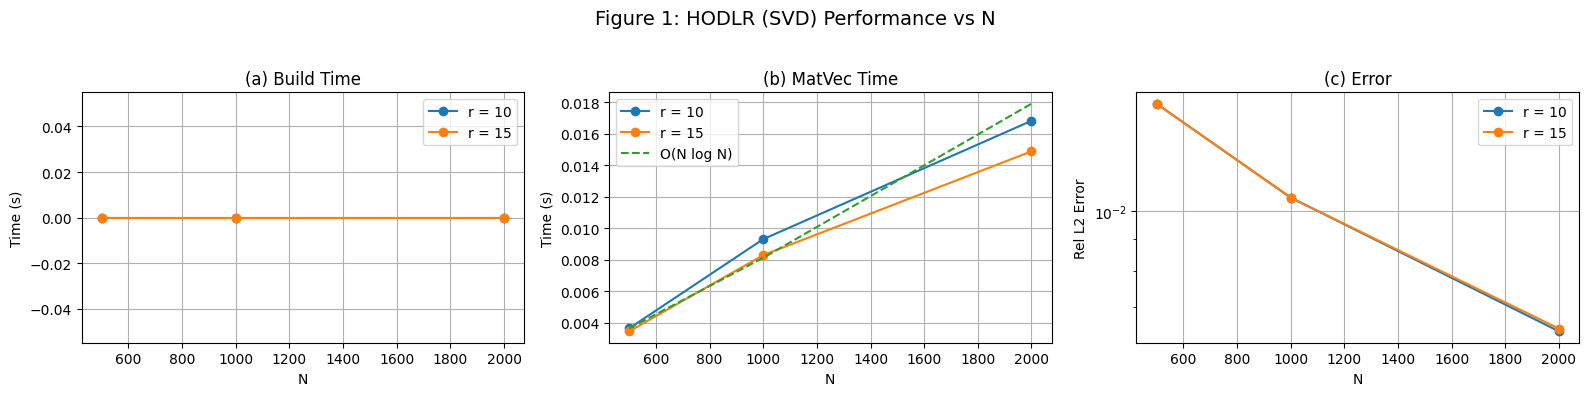

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))

# -------------------------------
# (a) Build Time
# -------------------------------
ax = axes[0]
for r in r_values:
    if len(build_svd[r]) == 0:
        continue
    ax.plot(Ns_used_svd[r], build_svd[r], marker='o', label=f"r = {r}")

ax.set_xlabel("N")
ax.set_ylabel("Time (s)")
ax.set_title("(a) Build Time")
ax.grid(True)
ax.legend()

# Save individual 1a
fig_a, ax_a = plt.subplots(figsize=(5,4))
for r in r_values:
    if len(build_svd[r]) == 0:
        continue
    ax_a.plot(Ns_used_svd[r], build_svd[r], marker='o', label=f"r = {r}")
ax_a.set_xlabel("N")
ax_a.set_ylabel("Time (s)")
ax_a.set_title("Figure 1(a): SVD Build Time")
ax_a.grid(True)
ax_a.legend()
fig_a.savefig("Figure_1a.png", dpi=300, bbox_inches="tight")
plt.close(fig_a)


# -------------------------------
# (b) MatVec Time
# -------------------------------
ax = axes[1]
for r in r_values:
    if len(matvec_svd[r]) == 0:
        continue
    ax.plot(Ns_used_svd[r], matvec_svd[r], marker='o', label=f"r = {r}")

for r in r_values:
    if len(Ns_used_svd[r]) > 0:
        ref_N = np.array(Ns_used_svd[r])
        ref = nlogn(ref_N)
        ref = ref / ref[0] * matvec_svd[r][0]
        ax.plot(ref_N, ref, '--', label="O(N log N)")
        break

ax.set_xlabel("N")
ax.set_ylabel("Time (s)")
ax.set_title("(b) MatVec Time")
ax.grid(True)
ax.legend()

# Save individual 1b
fig_b, ax_b = plt.subplots(figsize=(5,4))
for r in r_values:
    if len(matvec_svd[r]) == 0:
        continue
    ax_b.plot(Ns_used_svd[r], matvec_svd[r], marker='o', label=f"r = {r}")
for r in r_values:
    if len(Ns_used_svd[r]) > 0:
        ref_N = np.array(Ns_used_svd[r])
        ref = nlogn(ref_N)
        ref = ref / ref[0] * matvec_svd[r][0]
        ax_b.plot(ref_N, ref, '--', label="O(N log N)")
        break
ax_b.set_xlabel("N")
ax_b.set_ylabel("Time (s)")
ax_b.set_title("Figure 1(b): SVD MatVec Time")
ax_b.grid(True)
ax_b.legend()
fig_b.savefig("Figure_1b.png", dpi=300, bbox_inches="tight")
plt.close(fig_b)


# -------------------------------
# (c) Error
# -------------------------------
ax = axes[2]
for r in r_values:
    if len(err_svd[r]) == 0:
        continue
    ax.plot(Ns_used_svd[r], err_svd[r], marker='o', label=f"r = {r}")

ax.set_yscale("log")
ax.set_xlabel("N")
ax.set_ylabel("Rel L2 Error")
ax.set_title("(c) Error")
ax.grid(True)
ax.legend()

# Save individual 1c
fig_c, ax_c = plt.subplots(figsize=(5,4))
for r in r_values:
    if len(err_svd[r]) == 0:
        continue
    ax_c.plot(Ns_used_svd[r], err_svd[r], marker='o', label=f"r = {r}")
ax_c.set_yscale("log")
ax_c.set_xlabel("N")
ax_c.set_ylabel("Rel L2 Error")
ax_c.set_title("Figure 1(c): SVD Error")
ax_c.grid(True)
ax_c.legend()
fig_c.savefig("Figure_1c.png", dpi=300, bbox_inches="tight")
plt.close(fig_c)


# -------------------------------
# Full Figure
# -------------------------------
fig.suptitle("Figure 1: HODLR (SVD) Performance vs N", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig("Figure_1.png", dpi=300, bbox_inches="tight")

plt.show()

FIGURE 2 (CHEBYSHEV)

In [25]:
build_cheb, matvec_cheb, err_cheb = {}, {}, {}
Ns_used_cheb = {}

# Initialize
for p in p_values:
    build_cheb[p], matvec_cheb[p], err_cheb[p] = [], [], []
    Ns_used_cheb[p] = []

for N in N_cheb:

    # ------------------------
    # Dense (from results)
    # ------------------------
    if N not in results["dense"]:
        continue

    dense_entry = results["dense"][N]
    kde_dense = dense_entry["kde"]
    h_dense = dense_entry["fit"]["h_opt"]

    _, out_dense = measure_time(lambda: kde_dense.forward(h_dense))
    F_dense = out_dense[0] if isinstance(out_dense, (tuple, list)) else out_dense

    # ------------------------
    # Chebyshev
    # ------------------------
    for p in p_values:

        # Skip missing runs
        if p not in results["cheb"] or N not in results["cheb"][p]:
            continue

        entry = results["cheb"][p][N]

        kde = entry["kde"]
        h_opt = entry["fit"]["h_opt"]

        # Build time (correct for Cheb — one-time)
        build_cheb[p].append(entry["fit"]["time_build"])

        # Matvec
        t_m, out = measure_time(lambda: kde.forward(h_opt))
        F = out[0] if isinstance(out, (tuple, list)) else out

        matvec_cheb[p].append(t_m)

        # Error vs dense
        err_cheb[p].append(rel_l2(F, F_dense))

        # Track valid N
        Ns_used_cheb[p].append(N)

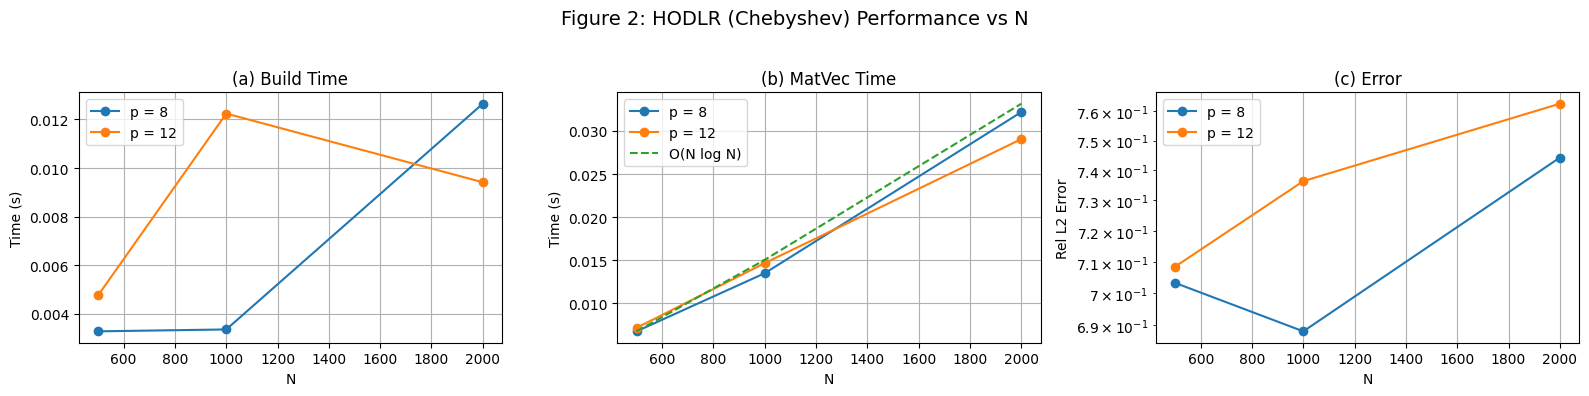

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))

# -------------------------------
# (a) Build Time
# -------------------------------
ax = axes[0]
for p in p_values:
    if len(build_cheb[p]) == 0:
        continue
    ax.plot(Ns_used_cheb[p], build_cheb[p], marker='o', label=f"p = {p}")

ax.set_xlabel("N")
ax.set_ylabel("Time (s)")
ax.set_title("(a) Build Time")
ax.grid(True)
ax.legend()

# Save individual 2a
fig_a, ax_a = plt.subplots(figsize=(5,4))
for p in p_values:
    if len(build_cheb[p]) == 0:
        continue
    ax_a.plot(Ns_used_cheb[p], build_cheb[p], marker='o', label=f"p = {p}")
ax_a.set_xlabel("N")
ax_a.set_ylabel("Time (s)")
ax_a.set_title("Figure 2(a): Chebyshev Build Time")
ax_a.grid(True)
ax_a.legend()
fig_a.savefig("Figure_2a.png", dpi=300, bbox_inches="tight")
plt.close(fig_a)


# -------------------------------
# (b) MatVec Time
# -------------------------------
ax = axes[1]
for p in p_values:
    if len(matvec_cheb[p]) == 0:
        continue
    ax.plot(Ns_used_cheb[p], matvec_cheb[p], marker='o', label=f"p = {p}")

for p in p_values:
    if len(Ns_used_cheb[p]) > 0:
        ref_N = np.array(Ns_used_cheb[p])
        ref = nlogn(ref_N)
        ref = ref / ref[0] * matvec_cheb[p][0]
        ax.plot(ref_N, ref, '--', label="O(N log N)")
        break

ax.set_xlabel("N")
ax.set_ylabel("Time (s)")
ax.set_title("(b) MatVec Time")
ax.grid(True)
ax.legend()

# Save individual 2b
fig_b, ax_b = plt.subplots(figsize=(5,4))
for p in p_values:
    if len(matvec_cheb[p]) == 0:
        continue
    ax_b.plot(Ns_used_cheb[p], matvec_cheb[p], marker='o', label=f"p = {p}")

for p in p_values:
    if len(Ns_used_cheb[p]) > 0:
        ref_N = np.array(Ns_used_cheb[p])
        ref = nlogn(ref_N)
        ref = ref / ref[0] * matvec_cheb[p][0]
        ax_b.plot(ref_N, ref, '--', label="O(N log N)")
        break

ax_b.set_xlabel("N")
ax_b.set_ylabel("Time (s)")
ax_b.set_title("Figure 2(b): Chebyshev MatVec Time")
ax_b.grid(True)
ax_b.legend()
fig_b.savefig("Figure_2b.png", dpi=300, bbox_inches="tight")
plt.close(fig_b)


# -------------------------------
# (c) Error
# -------------------------------
ax = axes[2]
for p in p_values:
    if len(err_cheb[p]) == 0:
        continue
    ax.plot(Ns_used_cheb[p], err_cheb[p], marker='o', label=f"p = {p}")

ax.set_yscale("log")
ax.set_xlabel("N")
ax.set_ylabel("Rel L2 Error")
ax.set_title("(c) Error")
ax.grid(True)
ax.legend()

# Save individual 2c
fig_c, ax_c = plt.subplots(figsize=(5,4))
for p in p_values:
    if len(err_cheb[p]) == 0:
        continue
    ax_c.plot(Ns_used_cheb[p], err_cheb[p], marker='o', label=f"p = {p}")

ax_c.set_yscale("log")
ax_c.set_xlabel("N")
ax_c.set_ylabel("Rel L2 Error")
ax_c.set_title("Figure 2(c): Chebyshev Error")
ax_c.grid(True)
ax_c.legend()
fig_c.savefig("Figure_2c.png", dpi=300, bbox_inches="tight")
plt.close(fig_c)


# -------------------------------
# Full Figure
# -------------------------------
fig.suptitle("Figure 2: HODLR (Chebyshev) Performance vs N", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig("Figure_2.png", dpi=300, bbox_inches="tight")

plt.show()

FIGURE 3 (TOTAL KDE TIME)

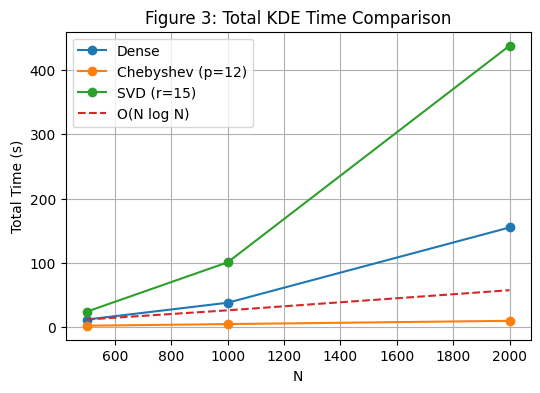

In [27]:
dense_t, cheb_t, svd_t = [], [], []
N_used = []

for N in N_dense:

    # Check all exist
    if (N not in results["dense"] or
        p_fixed not in results["cheb"] or
        N not in results["cheb"][p_fixed] or
        r_fixed not in results["svd"] or
        N not in results["svd"][r_fixed]):
        continue

    N_used.append(N)

    dense_t.append(results["dense"][N]["fit"]["total_time"])
    cheb_t.append(results["cheb"][p_fixed][N]["fit"]["total_time"])
    svd_t.append(results["svd"][r_fixed][N]["fit"]["total_time"])


plt.figure(figsize=(6,4))

plt.plot(N_used, dense_t, marker='o', label="Dense")
plt.plot(N_used, cheb_t, marker='o', label=f"Chebyshev (p={p_fixed})")
plt.plot(N_used, svd_t, marker='o', label=f"SVD (r={r_fixed})")

# Reference curve
if len(N_used) > 0:
    ref = nlogn(np.array(N_used))
    ref = ref / ref[0] * dense_t[0]
    plt.plot(N_used, ref, '--', label="O(N log N)")

plt.xlabel("N")
plt.ylabel("Total Time (s)")
plt.title("Figure 3: Total KDE Time Comparison")
plt.grid(True)
plt.legend()

plt.savefig("Figure_3_Total_Time.png", dpi=300, bbox_inches="tight")
plt.show()

FIGURE 4 (GD TIME)

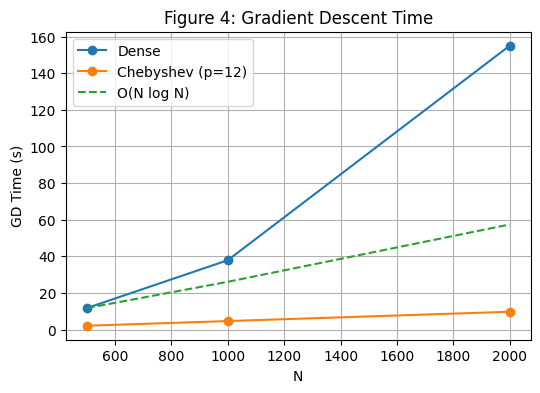

In [28]:
dense_t, cheb_t = [], []
N_used = []

for N in N_dense:

    if (N not in results["dense"] or
        p_fixed not in results["cheb"] or
        N not in results["cheb"][p_fixed]):
        continue

    N_used.append(N)

    dense_t.append(results["dense"][N]["fit"]["time_grad"])
    cheb_t.append(results["cheb"][p_fixed][N]["fit"]["time_grad"])


plt.figure(figsize=(6,4))

plt.plot(N_used, dense_t, marker='o', label="Dense")
plt.plot(N_used, cheb_t, marker='o', label=f"Chebyshev (p={p_fixed})")

# Reference curve
if len(N_used) > 0:
    ref = nlogn(np.array(N_used))
    ref = ref / ref[0] * dense_t[0]
    plt.plot(N_used, ref, '--', label="O(N log N)")

plt.xlabel("N")
plt.ylabel("GD Time (s)")
plt.title("Figure 4: Gradient Descent Time")
plt.grid(True)
plt.legend()

plt.savefig("Figure_4_GD_Time.png", dpi=300, bbox_inches="tight")
plt.show()

FIGURE 5 (SPEEDUP)

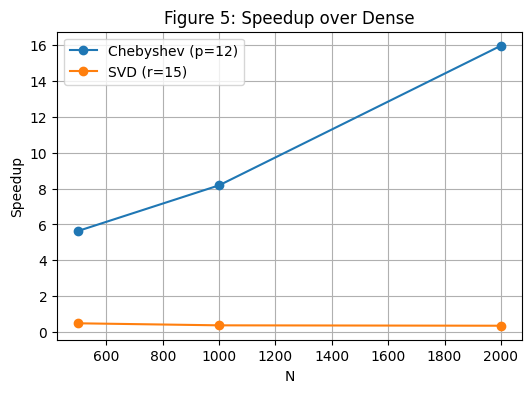

In [29]:
N_vals = [500, 1000, 2000,3000, 5000]

cheb_s, svd_s = [], []
N_used = []

for N in N_vals:

    if (N not in results["dense"] or
        p_fixed not in results["cheb"] or
        N not in results["cheb"][p_fixed] or
        r_fixed not in results["svd"] or
        N not in results["svd"][r_fixed]):
        continue

    td = results["dense"][N]["fit"]["total_time"]
    tc = results["cheb"][p_fixed][N]["fit"]["total_time"]
    ts = results["svd"][r_fixed][N]["fit"]["total_time"]

    cheb_s.append(td / tc)
    svd_s.append(td / ts)
    N_used.append(N)


plt.figure(figsize=(6,4))

plt.plot(N_used, cheb_s, marker='o', label=f"Chebyshev (p={p_fixed})")
plt.plot(N_used, svd_s, marker='o', label=f"SVD (r={r_fixed})")

plt.xlabel("N")
plt.ylabel("Speedup")
plt.title("Figure 5: Speedup over Dense")
plt.grid(True)
plt.legend()

plt.savefig("Figure_5_Speedup.png", dpi=300, bbox_inches="tight")
plt.show()

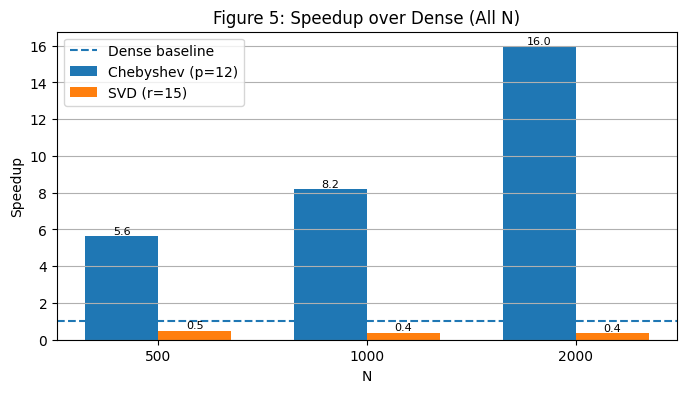

In [30]:
import numpy as np
import matplotlib.pyplot as plt

cheb_s, svd_s = [], []
N_used = []

# Use all N available in dense (sorted for clean plot)
all_N = sorted(results["dense"].keys())

for N in all_N:

    if (p_fixed not in results["cheb"] or
        N not in results["cheb"][p_fixed] or
        r_fixed not in results["svd"] or
        N not in results["svd"][r_fixed]):
        continue

    td = results["dense"][N]["fit"]["total_time"]
    tc = results["cheb"][p_fixed][N]["fit"]["total_time"]
    ts = results["svd"][r_fixed][N]["fit"]["total_time"]

    cheb_s.append(td / tc)
    svd_s.append(td / ts)
    N_used.append(N)

# Bar positions
x = np.arange(len(N_used))
width = 0.35

plt.figure(figsize=(8,4))

# Bars
plt.bar(x - width/2, cheb_s, width, label=f"Chebyshev (p={p_fixed})")
plt.bar(x + width/2, svd_s, width, label=f"SVD (r={r_fixed})")

# Dense baseline
plt.axhline(1, linestyle='--', linewidth=1.5, label="Dense baseline")

# Labels
plt.xticks(x, N_used)
plt.xlabel("N")
plt.ylabel("Speedup")
plt.title("Figure 5: Speedup over Dense (All N)")
plt.grid(True, axis='y')
plt.legend()

# Optional: value labels
for i, v in enumerate(cheb_s):
    plt.text(i - width/2, v, f"{v:.1f}", ha='center', va='bottom', fontsize=8)

for i, v in enumerate(svd_s):
    plt.text(i + width/2, v, f"{v:.1f}", ha='center', va='bottom', fontsize=8)

plt.savefig("Figure_5_Speedup_Bar.png", dpi=300, bbox_inches="tight")
plt.show()

FIGURE 6 (LOSS SMALL N)

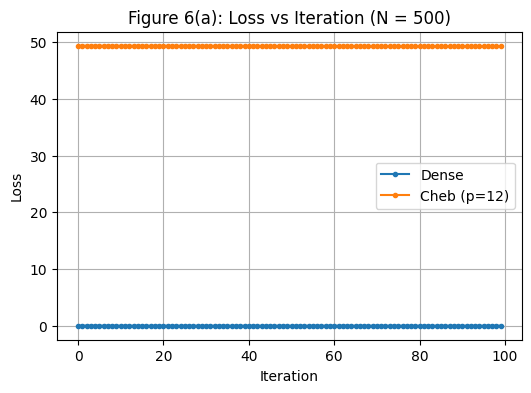

In [31]:
loss_d = np.array(results["dense"][500]["fit"]["losses"])
loss_c = np.array(results["cheb"][p_fixed][500]["fit"]["losses"])

plt.figure(figsize=(6,4))

plt.plot(loss_d, marker='o', markersize=3, label="Dense")
plt.plot(loss_c, marker='o', markersize=3, label=f"Cheb (p={p_fixed})")

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Figure 6(a): Loss vs Iteration (N = 500)")

plt.grid(True)
plt.legend()

plt.savefig("Figure_6_Loss_SmallN.png", dpi=300, bbox_inches="tight")
plt.show()

FIGURE 7 (LOSS LARGE N)

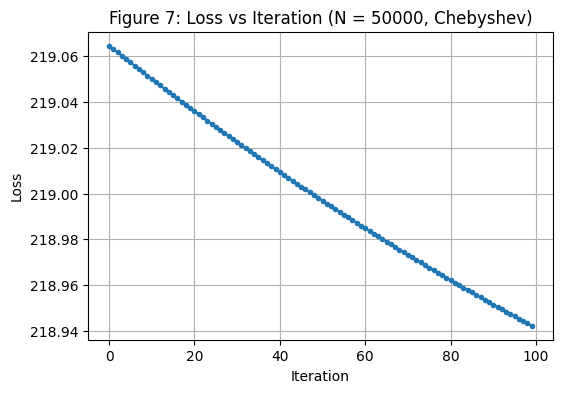

In [32]:
loss_c = np.array(results["cheb"][p_fixed][2000]["fit"]["losses"])

plt.figure(figsize=(6,4))

plt.plot(loss_c, marker='o', markersize=3)

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Figure 7: Loss vs Iteration (N = 2000, Chebyshev)")

plt.grid(True)

plt.savefig("Figure_7_Loss_LargeN.png", dpi=300, bbox_inches="tight")
plt.show()

FIGURE 8 (TRUE vs KDE)

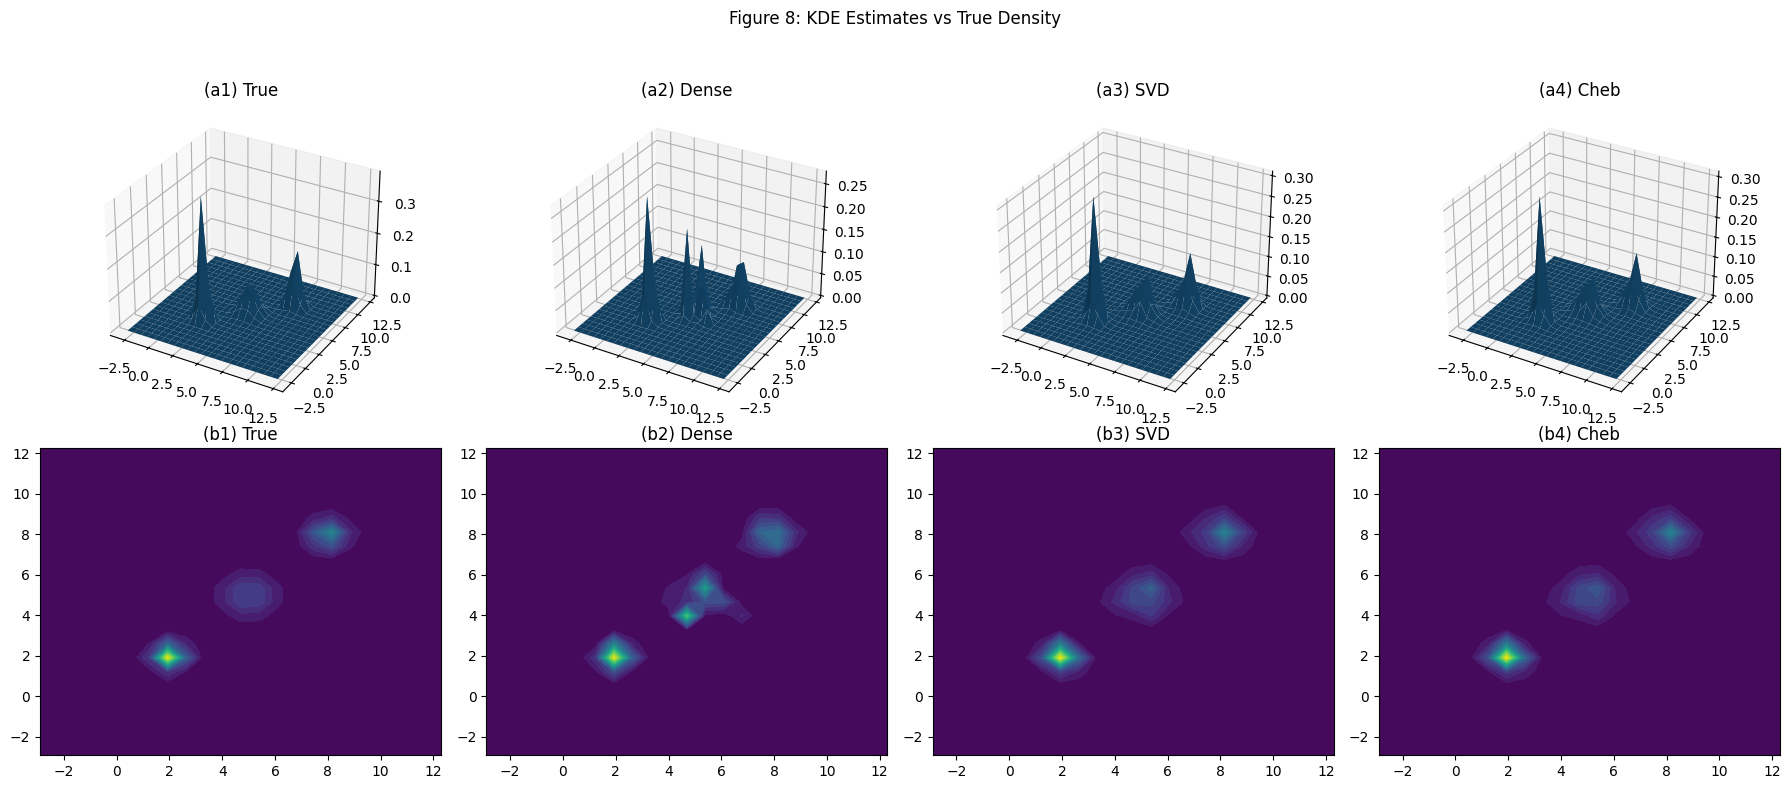

In [33]:
N = 500

# ------------------------
# Extract results
# ------------------------
dense_entry = results["dense"][N]
svd_entry   = results["svd"][r_fixed][N]
cheb_entry  = results["cheb"][p_fixed][N]

X = dense_entry["kde"].X
Z = dense_entry["kde"].Z

# ------------------------
# Compute densities
# ------------------------
model = KDE2D_Dense(X, Z)

f_true  = true_mixture_2d(Z)
f_dense = model.kde_estimate(dense_entry["fit"]["h_opt"], Z)
f_svd   = model.kde_estimate(svd_entry["fit"]["h_opt"], Z)
f_cheb  = model.kde_estimate(cheb_entry["fit"]["h_opt"], Z)

fields = [f_true, f_dense, f_svd, f_cheb]
titles = ["True", "Dense", "SVD", "Cheb"]

# ------------------------
# Grid from Z
# ------------------------
n = int(np.sqrt(len(Z)))
Xg = Z[:,0].reshape(n,n)
Yg = Z[:,1].reshape(n,n)

# ------------------------
# Figure 8 (2 rows x 4 cols)
# ------------------------
fig = plt.figure(figsize=(18,8))

# ---------- Top row: 3D ----------
for i in range(4):
    ax = fig.add_subplot(2,4,i+1, projection='3d')
    ax.plot_surface(Xg, Yg, fields[i].reshape(n,n))
    ax.set_title(f"(a{i+1}) {titles[i]}")

# ---------- Bottom row: Contour ----------
for i in range(4):
    ax = fig.add_subplot(2,4,4+i+1) 
    ax.contourf(Xg, Yg, fields[i].reshape(n,n), levels=20)
    ax.set_title(f"(b{i+1}) {titles[i]}")

plt.suptitle("Figure 8: KDE Estimates vs True Density")

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("Figure_8_combined.png", dpi=300, bbox_inches="tight")

plt.show()

FIGURE 9 (REL ERROR)

In [49]:
errors_dense = []
errors_cheb = {p: [] for p in p_values}
errors_svd = {r: [] for r in r_values}

for N in N_dense:
    print(f"\nN = {N}")

    # ------------------
    # Same grid
    # ------------------
    Z = results["dense"][N]["kde"].Z
    Ft = true_mixture_2d(Z)

    # ------------------
    # Dense
    # ------------------
    kde_d = results["dense"][N]["kde"]
    h_d = results["dense"][N]["fit"]["h_opt"]

    Fd = kde_d.kde_estimate(h_d, Z)
    err_d = rel_l2(Fd, Ft)

    errors_dense.append(err_d)

    print(f"  Dense Error      : {err_d:.4e}")

    # ------------------
    # SVD
    # ------------------
    for r in r_values:
        kde_s = results["svd"][r][N]["kde"]
        h_s = results["svd"][r][N]["fit"]["h_opt"]
    
        Fs = kde_s.kde_estimate(h_s, Z)
        err_s = rel_l2(Fs, Ft)
    
        errors_svd[r].append(err_s)
        print(f"  SVD (r={r}) Error  : {err_s:.4e}")
        
    # ------------------
    # Chebyshev
    # ------------------
    for p in p_values:
        kde = results["cheb"][p][N]["kde"]
        h_c = results["cheb"][p][N]["fit"]["h_opt"]

        Fc = kde.kde_estimate(h_c, Z)
        err_c = rel_l2(Fc, Ft)

        errors_cheb[p].append(err_c)

        print(f"  Cheb (p={p}) Error: {err_c:.4e}")


N = 500
  Dense Error      : 4.8557e-01
  SVD (r=10) Error  : 2.3116e-01
  SVD (r=15) Error  : 2.3110e-01
  Cheb (p=8) Error: 2.4611e-01
  Cheb (p=12) Error: 2.2011e-01

N = 1000
  Dense Error      : 4.7330e-01
  SVD (r=10) Error  : 2.6382e-01
  SVD (r=15) Error  : 2.6405e-01
  Cheb (p=8) Error: 2.6612e-01
  Cheb (p=12) Error: 2.4369e-01

N = 2000
  Dense Error      : 6.7095e-01
  SVD (r=10) Error  : 2.7185e-01
  SVD (r=15) Error  : 2.7143e-01
  Cheb (p=8) Error: 2.6002e-01
  Cheb (p=12) Error: 2.7897e-01


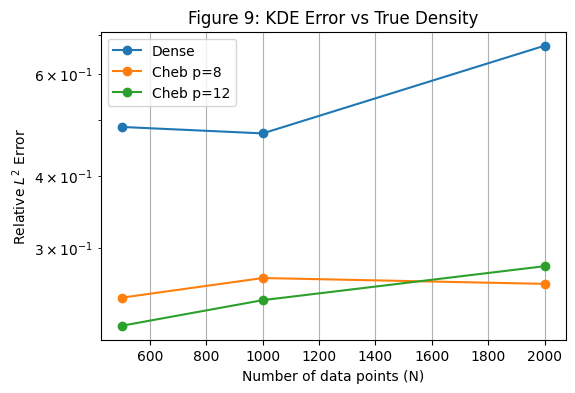

In [35]:
plt.figure(figsize=(6,4))

plt.plot(N_dense, errors_dense, marker='o', label="Dense")

for p in p_values:
    plt.plot(N_dense, errors_cheb[p], marker='o', label=f"Cheb p={p}")

plt.yscale("log")

plt.xlabel("Number of data points (N)")
plt.ylabel("Relative $L^2$ Error")

plt.title("Figure 9: KDE Error vs True Density")

plt.grid(True)
plt.legend()

plt.savefig("Figure_9_Error.png", dpi=300, bbox_inches="tight")
plt.show()

# Demo

In [36]:
# def run_quick_demo_2d():

#     N_values = [1000]
#     ranks = [8]
#     leaf_sizes = [16]

#     results, N_values = run_scaling_experiment_2d(
#         N_values, ranks, leaf_sizes
#     )

#     return results, N_values

In [37]:
# results, N_values = run_quick_demo_2d()

In [38]:
# create_runtime_plot_2d(results, N_values)
# # create_gradient_time_plot(results, N_values)
# create_error_plot_2d(results, N_values)
# create_speedup_plot_2d(results, N_values)
# create_speedup_bar_plot_2d(results, N_values)
# print_timing_breakdown_2d(results, N_values)
# # visualization
# idx = -1
# dense_res = results['dense'][idx]
# svd_res   = list(results['svd'].values())[0][idx]
# cheb_res  = list(results['cheb'].values())[0][idx]

# plot_3d_all(dense_res, svd_res, cheb_res)
# plot_contour_all(dense_res, svd_res, cheb_res)